# Estimating powerplant Energy generation using ANN

In [1]:
import numpy as np

In [2]:
# Load Data
import pandas as pd

df = pd.read_csv("C:/Users/mayan/OneDrive/Desktop/Mayank(HP)/programs/Learning_AIML/Cleaned_data/powerplant_data.csv")

In [3]:
df.head()
# AT = Temperatuer
# V = vaccum
# AP = pressure
# RH = humidity

# PE = Produced Energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE",axis = 1)
y = df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
# Split out Data
from sklearn.model_selection import train_test_split

X_train , X_test , y_train, y_test = train_test_split(
    X , y,test_size= 0.2 , random_state = 42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [11]:
import torch 
import torch.nn as nn

In [12]:
# Convert data into tensors 

X_train_tensor = torch.tensor(X_train_scaled , dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1 ,1)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1 ,1)

# .values is written because y_train is not a numpy array 
# .view = we are changing the dimensions of y_tain by this ,[1,2,3,..] =>[[1],[2],[3]..]

In [13]:
from torch.utils.data import TensorDataset , DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [14]:
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True )
test_loader = DataLoader(train_dataset , batch_size = 32 )

## DEEP LEARNING

In [20]:
# Define  ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN , self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer 
            nn.Linear(6,1),
        )

    def forward(self , x):
        return self.model(x)


In [21]:
import torch.optim as optim

model = ANN()

# loss , optimizer 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [22]:
# Training the ANN Model
train_losses = []
validation_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch
    
    for xb,yb in train_loader:
        # xb = features of 1 batch 
        # yb = labels of 1 batch

        optimizer.zero_grad() #make previous gradient zero for a fresh start

        outputs = model(xb) # forward prop ....predicted outputs for this batch
        loss = criterion(outputs , yb)# compute loss 
        loss.backward() # back prop ... compute gradients 
        optimizer.step() # params update

        running_loss += loss.item() # loss is tensor => py float 

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation in each epoch
    model.eval()
    runninng_val_loss = 0.0 

    with torch.no_grad(): # no gradient compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs , yb)
            runninng_val_loss += loss
            
    epoch_val_loss = runninng_val_loss / len(test_loader)
    validation_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1} ==> train Loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict() ,"best_model.pt")

epoch 1 ==> train Loss = 205979.56829427084 & val loss = 203418.96875
epoch 2 ==> train Loss = 194996.209375 & val loss = 182648.734375
epoch 3 ==> train Loss = 164206.89352213542 & val loss = 144283.9375
epoch 4 ==> train Loss = 126616.06549479166 & val loss = 112201.171875
epoch 5 ==> train Loss = 104488.69466145833 & val loss = 99429.546875
epoch 6 ==> train Loss = 95385.8140625 & val loss = 91394.7109375
epoch 7 ==> train Loss = 85783.86461588541 & val loss = 79378.2578125
epoch 8 ==> train Loss = 69775.36005859375 & val loss = 58114.125
epoch 9 ==> train Loss = 41906.7326171875 & val loss = 24847.1953125
epoch 10 ==> train Loss = 12159.300436401367 & val loss = 3870.736572265625
epoch 11 ==> train Loss = 1701.5583488464356 & val loss = 731.2074584960938
epoch 12 ==> train Loss = 550.6012229601542 & val loss = 450.13067626953125
epoch 13 ==> train Loss = 404.348637898763 & val loss = 362.2189636230469
epoch 14 ==> train Loss = 330.08563137054443 & val loss = 297.83184814453125
epoc

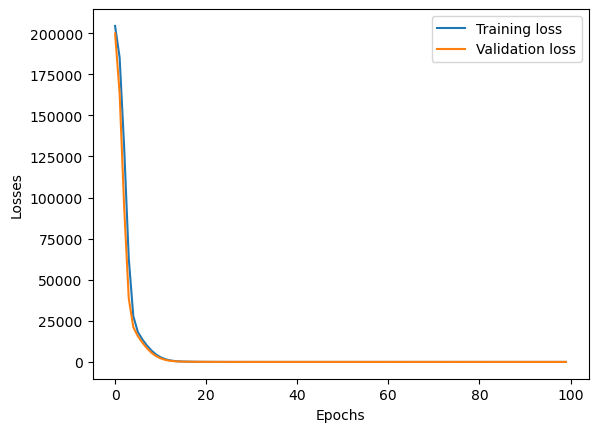

In [19]:
import matplotlib.pyplot as plt 

loss_df = pd.DataFrame({
    "Training loss":train_losses,
    "Validation loss": validation_losses 
})

plt.plot(loss_df["Training loss"] , label = "Training loss")
plt.plot(loss_df["Validation loss"] , label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [23]:
# Loading the best model 
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [26]:
# Evaluate our Model

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)
    
    train_mse_loss = criterion(train_pred , y_train_tensor)
    test_mse_loss = criterion(test_pred , y_test_tensor)

print("Training MSE : ",train_mse_loss.item())
print("Testing MSE : ",test_mse_loss.item())

Training MSE :  20.300872802734375
Testing MSE :  18.734704971313477


In [28]:
from sklearn.metrics import r2_score 

print("r2_score = ",r2_score(y_test , test_pred))

r2_score =  0.9345270392886472


In [29]:
predicted_df = pd.DataFrame(test_pred.numpy() , columns = [" Predicted values"])
actual_df = pd.DataFrame(y_test.values , columns = ["Actual values"])

pd.concat([predicted_df , actual_df] , axis =1 )

,Predicted values,Actual values
0,435.562378,433.27
1,436.796021,438.16
2,461.648804,458.42
3,476.543213,480.82
4,435.592224,441.41
...,...,...
1909,451.456848,456.70
1910,431.655579,438.04
1911,468.131561,467.80
1912,431.031982,437.14
